In [1]:
import numpy as np
from gfsupg.solver import CartesianGeometry, FiniteElement1D, Scipy2DFEM
from gfsupg.solver import DeC, ImplicitDec, DeCSpaceTimeSUPGSolver
from gfsupg.solver import ImplicitEuler

from gfsupg.plotting import *

from gfsupg.problem import *

import time
import scipy.sparse as sp

import matplotlib.pyplot as plt

In [2]:

#problem.T_fin = 1.
order=2

FEM1Dx = FiniteElement1D(order-1,"gaussLobatto","gaussLobatto")
FEM1Dy = FiniteElement1D(order-1,"gaussLobatto","gaussLobatto")
dec = DeC((order+1)//2,order,"gaussLobatto")
# dec = DeC(4,5,"gaussLobatto")


In [3]:
# problem = SmoothVortexTestCase(is_long=False, pert_coeff=1e-3, pert_type="opt") #LinearAdvection("smooth_vortex_long")
# problem = StommelGyreTestCase(is_long=False, pert_coeff=1e-3, pert_type="num") #LinearAdvection("smooth_vortex_long")
#problem = VortexTestCase(is_long=True) #LinearAdvection("smooth_vortex_long")
problem = CoriolisVortexTestCase(is_long=False) #LinearAdvection("smooth_vortex_long")
#problem.BC *= 0
#problem = CoriolisVortexTestCase(is_long=True)
#problem = ObliqueTestCase()
#problem.T_fin = 2.0

In [4]:

Ns = np.array([30,30], dtype=np.int32)

geom = CartesianGeometry(problem.xL,problem.xR, Ns, problem.geometry_folder, BC=problem.BC)

In [5]:
FEM2D = Scipy2DFEM(geom,FEM1Dx, FEM1Dy, folder=problem.folderName)

Assembled matrices in 0.032 seconds


In [ ]:
#solver = ImplicitDec(problem, FEM2D, dec, GF = True, stab = "SUPG", trick_second_der=False)
solver = DeCSpaceTimeSUPGSolver(problem, FEM2D, dec, GF = True, stab = "SUPG", trick_second_der=False)

In [ ]:
q, tt, comp_time, error , _  = solver.solve(CFL=0.5, with_error = True, save_sol = True)

In [ ]:
print(error)


In [ ]:
tt.shape

In [ ]:
for it in [0, 5, 10, 15, 20, 25, len(tt)-1]:
    t = tt[it]
    plot_all_sols(problem, FEM2D,q,it, t , 200)


In [ ]:
fig, axs = plt.subplots(1,problem.n_eq, figsize=(15,4))
for k, var in enumerate(problem.vars):
    ex = FEM2D.evaluate_function(lambda x,y: problem.exact[var](x,y,1))
    axs[k].set_title(var)
    plot_sol(FEM2D,ex, axs[k],fig) 


In [6]:
solver2 = ImplicitEuler(problem, FEM2D, dec, GF = True, stab = "SUPG", trick_second_der=False)

In [7]:
q, tt, comp_time, error , _  = solver2.solve(CFL=0.5, with_error = True, save_sol = True)

CFL number = 0.5
Iteration 0000060, time 1.00000, max vars 0.005  0.005  1.010 ,  min vars -0.005  -0.005  0.912 
Simulation over in 0.93 seconds
Computing exact solution and error



In [ ]:
print(error)


In [ ]:
tt.shape

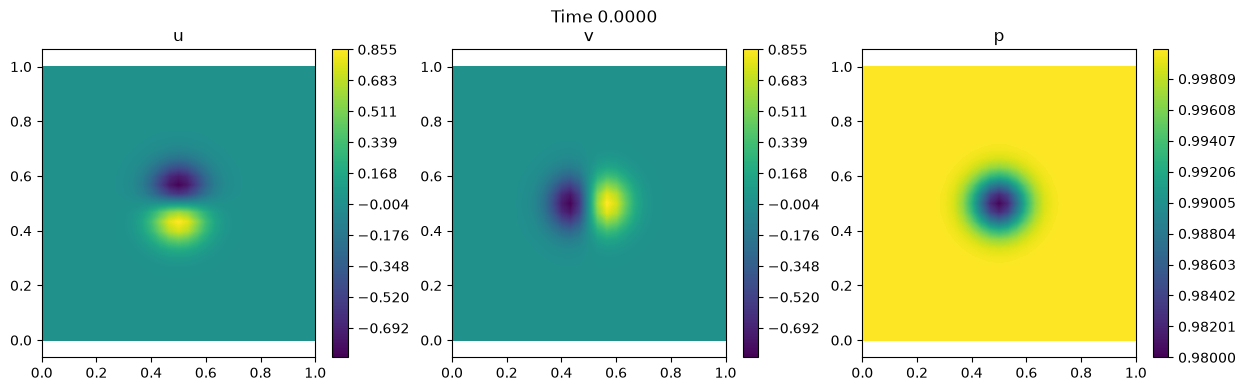

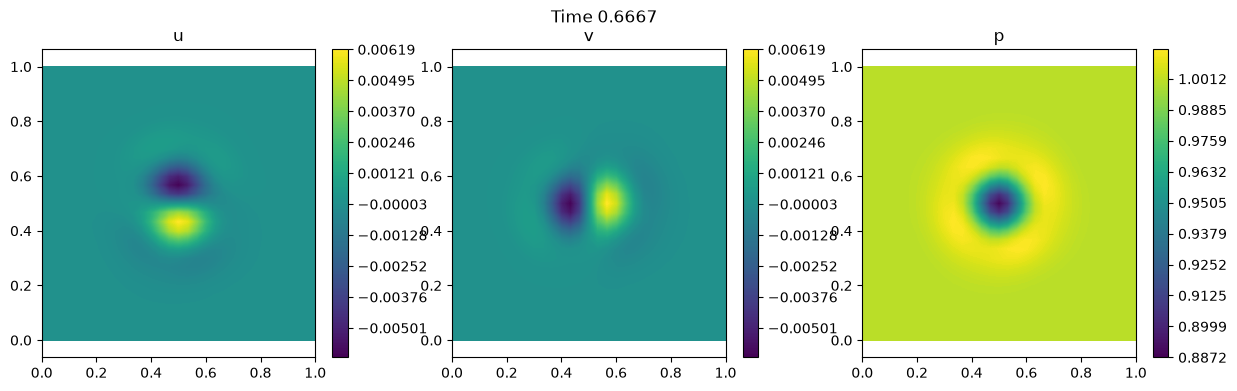

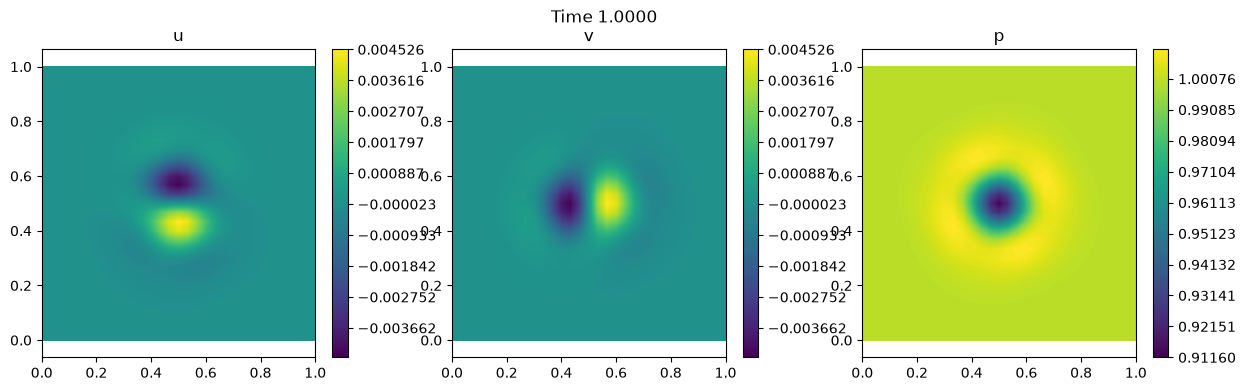

In [9]:
for it in [0, 5, 8]:#10, 15, 20, 25, len(tt)-1]:
    t = tt[it]
    plot_all_sols(problem, FEM2D,q,it, t , 200)


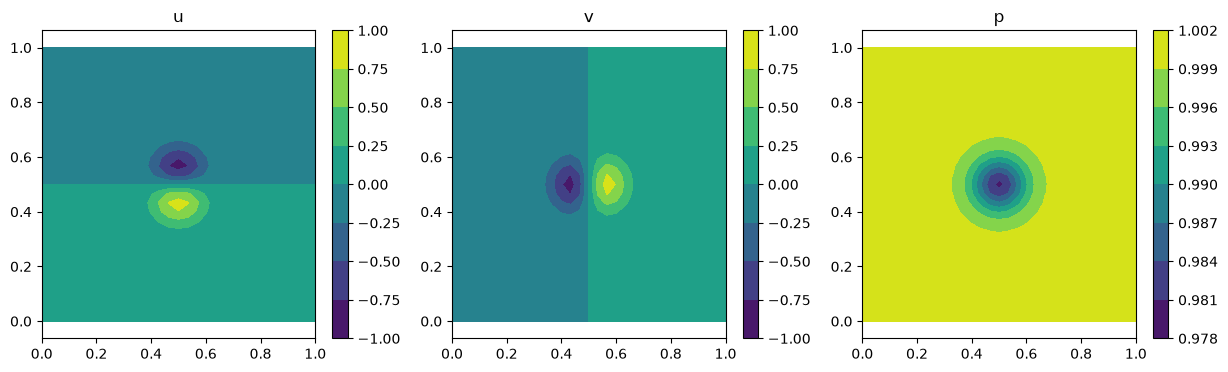

In [8]:
fig, axs = plt.subplots(1,problem.n_eq, figsize=(15,4))
for k, var in enumerate(problem.vars):
    ex = FEM2D.evaluate_function(lambda x,y: problem.exact[var](x,y,1))
    axs[k].set_title(var)
    plot_sol(FEM2D,ex, axs[k],fig) 


In [ ]:
from scipy import sparse

In [ ]:
sparse.eye(10)

In [ ]:
sparse.diags([10,1,20]).todense()